In [ ]:
from ccd_simulation import *
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                            AutoMinorLocator)
from matplotlib.offsetbox import AnchoredText
#Options
small = 16
smaller = 16
smallest = 12
large = 20
params = {'text.usetex' : True,
        'font.size' : small,
        'font.family' : 'serif',
        'figure.autolayout': True
        }
plt.rcParams.update(params)
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['axes.labelsize']=small
def format_sci(number):
    """
    Formats a float into scientific notation with 3 decimal places.
    Example: 12345.6789 -> "1.235e+04"
    """
    return "{:.3e}".format(number)


In [ ]:


UR_expdep = 4.36e-5 #e / pix / day


UR_expindep = 9.94e-5 #e / superpix / image

UR_expdep = UR_expdep / (24) #e / pix / hour




UR_expindep = UR_expindep#/ 32 #e / pix / image

rundir = './minos_ccd_sim_hotcolbias/'

rundir = './minos_ccd_sim/'
rundir = './minos_conditions/'
# rundir = './snolab2x_ccd_sim/'

num_images = 250 if 'hotcol' in rundir else 500
num_images = num_images if '2x' not in rundir else 231
mask = "None"
mask = 'Halo'
# mask = 'Halo+Bleed'
# mask = "Halo+Bleed+HotPixel"
# mask = "Halo+Bleed+HotColumn"
mask = 'Halo+Bleed+HotColumn+HotPixel'

In [3]:
UR_expindep,UR_expdep

(9.94e-05, 1.8166666666666667e-06)

In [4]:
import hist
from hist import Hist
import numpy as np
# if 'minos' in rundir:
lower_exp0 = 7e-5
upper_exp0 = 2e-4

lower_exp4 = 7e-5
upper_exp4 = 2e-4



lower_exp6 = 7e-5
upper_exp6 = 2e-4


lower_exp10 = 7e-5
upper_exp10 = 2e-4


lower_exp20 = 7e-5
upper_exp20 = 2e-4

nbins = 25



In [5]:
import pickle
import numpy as np
total_counts_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
total_pix_traps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}

total_counts_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
total_pix_notraps = {0: 0, 4: 0, 6: 0, 10: 0, 20: 0}
# lower = np.min(densities_exp)
histograms = {
    0: Hist(hist.axis.Regular(nbins, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(nbins, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(nbins, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(nbins, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(nbins, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

histograms_no_traps = {
    0: Hist(hist.axis.Regular(nbins, lower_exp0, upper_exp0, name="1e Densities Exp 0h")),
    4: Hist(hist.axis.Regular(nbins, lower_exp4, upper_exp4, name="1e Densities Exp 4h")),
    6: Hist(hist.axis.Regular(nbins, lower_exp6, upper_exp6, name="1e Densities Exp 6h")),
    10: Hist(hist.axis.Regular(nbins, lower_exp10, upper_exp10, name="1e Densities Exp 10h")),
    20: Hist(hist.axis.Regular(nbins, lower_exp20, upper_exp20, name="1e Densities Exp 20h")),

}

plot = False

colorlist = ['darkslategrey','rebeccapurple','dodgerblue','gold','firebrick']

for i in range(num_images):
    with open(f'{rundir}ccd_traps_run{i}.pkl','rb') as f:
        ccd_run = pickle.load(f)
        print(ccd_run.stats_trap.keys())

        

        unique_exposures = np.unique( np.sort(np.array(ccd_run.exposures)))

        if plot:
            fig,ax = plt.subplots(3,figsize=(10,12))
            fig.suptitle(f"CCD Run {i+1}")
            ax[0].set_ylabel('Masked 1e Counts')
            ax[1].set_ylabel('Unmasked Pixels')
            ax[2].set_ylabel('Unmasked 1e Counts')


        # ax[0,1].set_ylabel('Masked 1e Counts No Traps')
        # ax[1,1].set_ylabel('Unmasked Pixels No Traps')
        # ax[2,1].set_ylabel('Unmasked 1e Counts No Traps')

        for e in range(len(unique_exposures)):
            exp = unique_exposures[e]
            expkey = int(exp / 3600)
            # print(expkey)
            exp_indices = np.array(ccd_run.exposures) == exp

            # densities_exp = densities[exp_indices]
            # densities_exp_notraps = densities_notraps[exp_indices]


            counts = np.array(ccd_run.stats_trap[mask]['counts'])[exp_indices]
            counts_notraps = np.array(ccd_run.stats_notrap[mask]['counts'])[exp_indices]


            if mask == 'None':
                unmasked_pix = unmasked_pix_notraps = int(1024 /2) * int(6144 / 2)
                counts_masked = counts
                counts_masked_notraps = counts_notraps


            
            else:

                counts_masked = np.array(ccd_run.stats_trap[mask]['counts'])[exp_indices]
                unmasked_pix = np.array(ccd_run.stats_trap[mask]['unmasked_pix'])[exp_indices]


                counts_masked_notraps = np.array(ccd_run.stats_notrap[mask]['counts'])[exp_indices]
                unmasked_pix_notraps = np.array(ccd_run.stats_notrap[mask]['unmasked_pix'])[exp_indices]

            


            # counts_masked = np.array(ccd_run.single_e_counts_masked)[exp_indices]
            # counts = np.array(ccd_run.single_e_counts)[exp_indices]
            # unmasked_pix = np.array(ccd_run.unmasked_pixels)[exp_indices]

            # counts_masked_notraps = np.array(ccd_run.single_e_counts_masked_no_traps)[exp_indices]
            # counts_notraps = np.array(ccd_run.single_e_counts_no_traps)[exp_indices]

            # unmasked_pix_notraps = np.array(ccd_run.unmasked_pixels_no_traps)[exp_indices]

            densities_exp = counts_masked / unmasked_pix

            densities_exp_notraps = counts_masked_notraps / unmasked_pix_notraps



            if plot:
                ax[0].plot(counts_masked,label=f"{expkey}h Traps",color=colorlist[e])
                ax[0].plot(counts_masked,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])

                ax[1].plot(unmasked_pix,label=f"{expkey}h Traps",color=colorlist[e])
                ax[1].plot(unmasked_pix_notraps,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])

                ax[2].plot(counts,label=f"{expkey}h Traps",color=colorlist[e])
                ax[2].plot(counts_notraps,label=f"{expkey}h No Traps",ls='--',color=colorlist[e])
            

            print(f"Exposure: {expkey}h")

            print("Max: ", np.max(densities_exp))
            print("Min: ", np.min(densities_exp))


            total_counts_traps[expkey] += np.sum(counts_masked)
            total_pix_traps[expkey] += np.sum(unmasked_pix)

            total_counts_notraps[expkey] += np.sum(counts_masked_notraps)
            total_pix_notraps[expkey] += np.sum(unmasked_pix_notraps)
            
            # mean_traps[expkey].append(np.sum(counts_masked) / np.sum(unmasked_pix))

            # mean_traps_err[expkey].append(np.sqrt(np.sum(counts_masked)) / np.sum(unmasked_pix))

            # mean_notraps[expkey].append(np.sum(counts_masked_notraps) / np.sum(unmasked_pix_notraps))
            # mean_notraps_err[expkey].append(np.sqrt(np.sum(counts_masked_notraps))/ np.sum(unmasked_pix_notraps))

            histograms[expkey].fill(densities_exp)
            histograms_no_traps[expkey].fill(densities_exp_notraps)
        if plot:
            ax[0].legend()
            ax[1].legend()
            ax[2].legend()
            plt.tight_layout()
            plt.show()
            plt.close()
        del ccd_run







dict_keys(['None', 'Halo', 'Bleed', 'HotColumn', 'HotPixel', 'Halo+Bleed', 'Halo+HotColumn', 'Halo+HotPixel', 'Bleed+HotColumn', 'Bleed+HotPixel', 'HotColumn+HotPixel', 'Halo+Bleed+HotColumn', 'Halo+Bleed+HotPixel', 'Halo+HotColumn+HotPixel', 'Bleed+HotColumn+HotPixel', 'Halo+Bleed+HotColumn+HotPixel'])
Exposure: 0h
Max:  0.00011728461129764847
Min:  8.203513795682516e-05
Exposure: 4h
Max:  0.0001346923382100123
Min:  8.115415319610637e-05
Exposure: 6h
Max:  0.00013970225393813895
Min:  8.459416465325678e-05
Exposure: 10h
Max:  0.00014268939398898018
Min:  9.271762490728237e-05
Exposure: 20h
Max:  0.0001842431840610586
Min:  8.58152207596554e-05
dict_keys(['None', 'Halo', 'Bleed', 'HotColumn', 'HotPixel', 'Halo+Bleed', 'Halo+HotColumn', 'Halo+HotPixel', 'Bleed+HotColumn', 'Bleed+HotPixel', 'HotColumn+HotPixel', 'Halo+Bleed+HotColumn', 'Halo+Bleed+HotPixel', 'Halo+HotColumn+HotPixel', 'Bleed+HotColumn+HotPixel', 'Halo+Bleed+HotColumn+HotPixel'])
Exposure: 0h
Max:  0.00012169291497444129

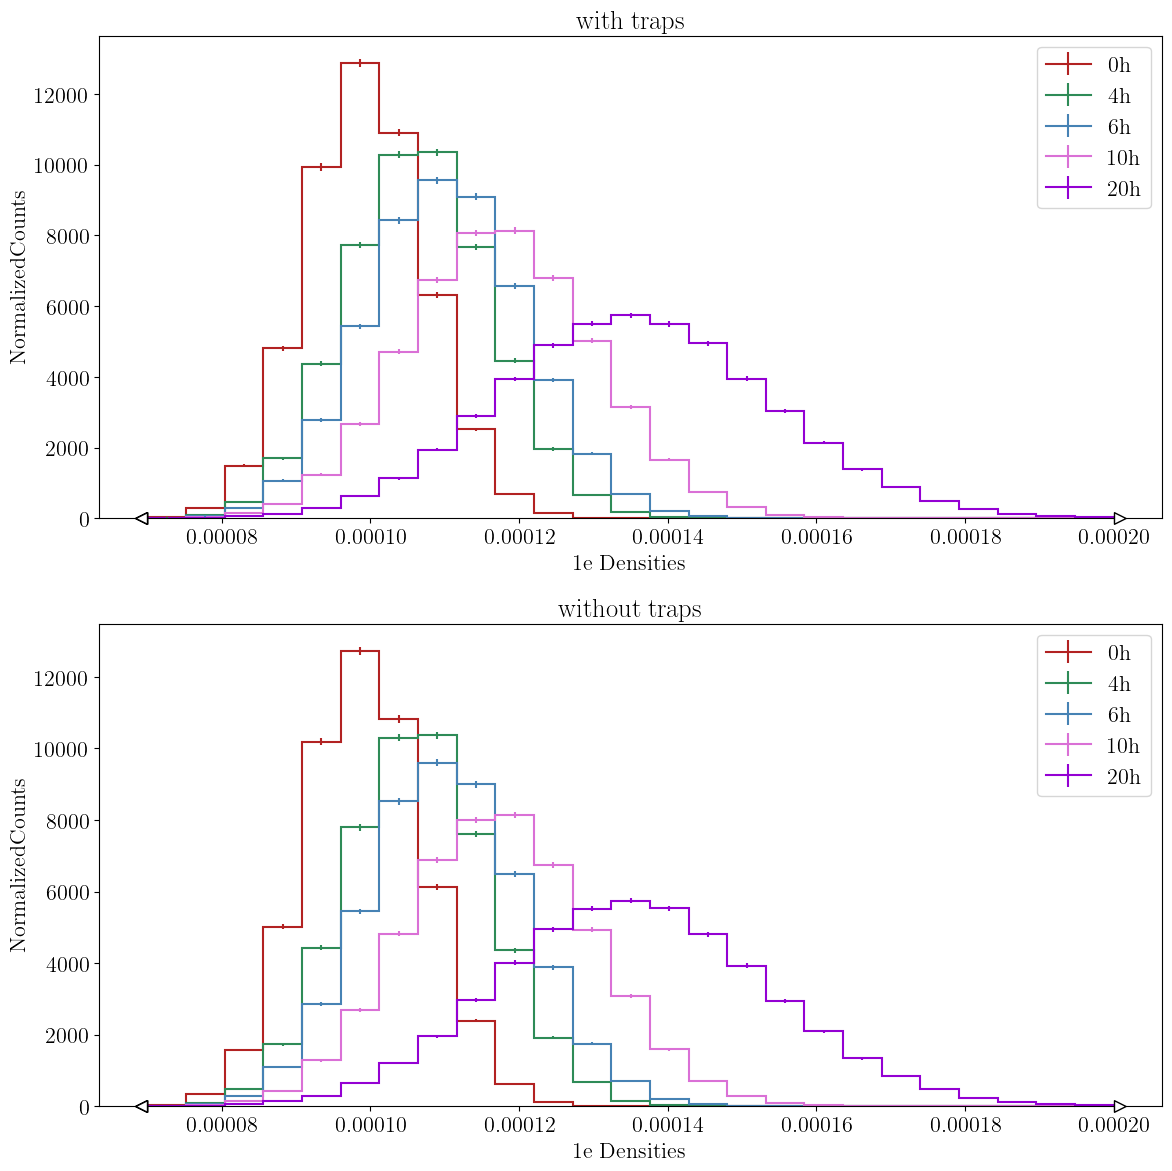

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
colorlist = ['firebrick','seagreen','steelblue','orchid','darkviolet']
fig, ax = plt.subplots(2,figsize=(12,12))
for i in range(2):
    if i == 0:
        hists = histograms
        t = 'with'
    elif i == 1:
        hists = histograms_no_traps
        t = 'without'
    for j,h in enumerate([0,4,6,10,20]):
        color = colorlist[j]
        plothist = hists[h] #/ np.sum(hists[h].values())

        plothist.plot1d(ax=ax[i],color=color,label=f'{h}h')
    # hists[4].plot1d(ax=ax[i],color='seagreen',label='4h')
    # hists[6].plot1d(ax=ax[i],color='steelblue',label='6h')
    # hists[10].plot1d(ax=ax[i],color='orchid',label='10h')
    # hists[20].plot1d(ax=ax[i],color='darkviolet',label='20h')

    # ax[i].set_ylim(50)
    ax[i].set_title(f"{t} traps")
    ax[i].set_ylabel("NormalizedCounts")
    ax[i].set_xlabel("1e Densities")
    ax[i].legend()
plt.tight_layout()
plt.show()
plt.close()

plt.figure()

# histograms[20]

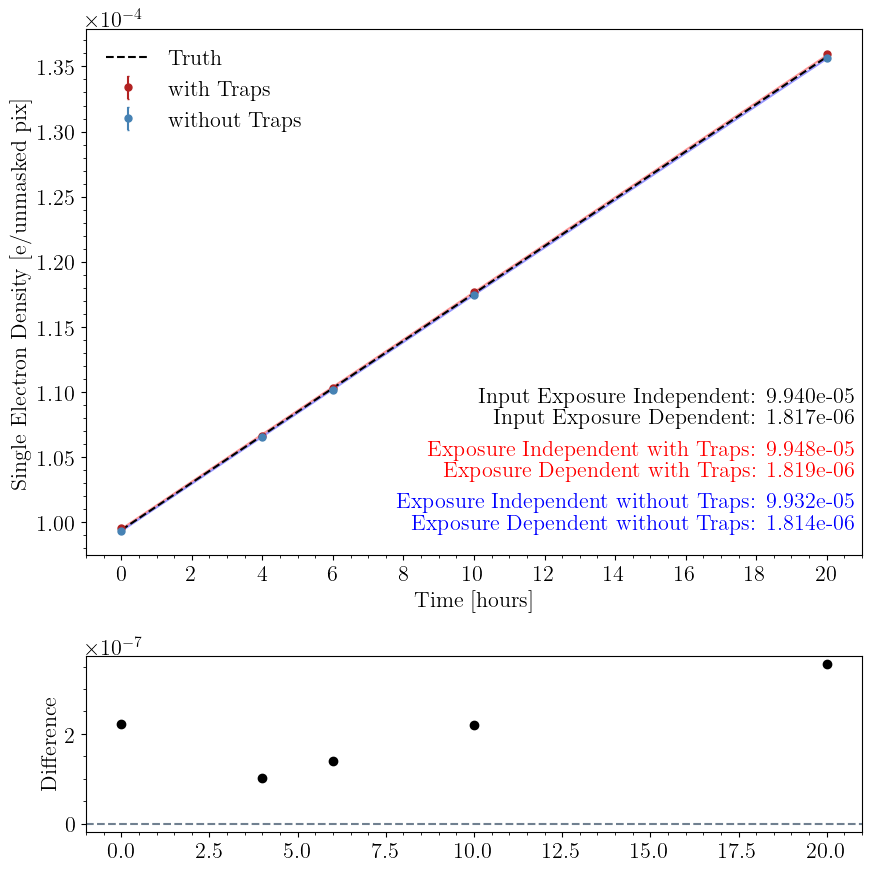

In [ ]:
unique_exposures_h = unique_exposures / 3600
unique_exposures_h = unique_exposures_h.astype(int)



average_densities = []
average_density_errs = []
average_densities_notraps = []
average_density_errs_notraps = []

for h in unique_exposures_h:
    # Traps: Mean = Total Counts / Total Pixels
    mean_t = total_counts_traps[h] / total_pix_traps[h]
    # Poisson Error = sqrt(Total Counts) / Total Pixels
    err_t = np.sqrt(total_counts_traps[h]) / total_pix_traps[h]
    
    average_densities.append(mean_t)
    average_density_errs.append(err_t)

    # No Traps
    mean_nt = total_counts_notraps[h] / total_pix_notraps[h]
    err_nt = np.sqrt(total_counts_notraps[h]) / total_pix_notraps[h]
    
    average_densities_notraps.append(mean_nt)
    average_density_errs_notraps.append(err_nt)

average_densities = np.array(average_densities)
average_density_errs = np.array(average_density_errs)
average_densities_notraps = np.array(average_densities_notraps)
average_density_errs_notraps = np.array(average_density_errs_notraps)



from scipy.optimize import curve_fit

def format_sci(number):
    """
    Formats a float into scientific notation with 3 decimal places.
    Example: 12345.6789 -> "1.235e+04"
    """
    return "{:.3e}".format(number)


def line(x,m,b):
    y = m*x + b
    return y


# days = unique_exposures_h.reshape((-1, 1))

popt, pcov = curve_fit(line, unique_exposures_h, average_densities, sigma=average_density_errs, absolute_sigma=True)
exp_dep, exp_indep = popt



popt, pcov = curve_fit(line, unique_exposures_h, average_densities_notraps, sigma=average_density_errs_notraps, absolute_sigma=True)

# model_notraps = LinearRegression().fit(days, average_densities_notraps)

# exp_indep_notraps = model_notraps.intercept_
# exp_dep_notraps = model_notraps.coef_[0]

exp_dep_notraps, exp_indep_notraps = popt


hours = np.linspace(0,20,20)




fit_no_traps = line(hours,exp_dep_notraps,exp_indep_notraps)
fit_traps = line(hours,exp_dep,exp_indep)


# plt.figure(figsize=(12,6))
# ax = plt.gca()
fig,axes = plt.subplots(2,figsize=(9,9),gridspec_kw={'height_ratios': [3, 1]})
ax= axes[0]
formatter = tck.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0)) # Forces scientific notation for all values
ax.yaxis.set_major_formatter(formatter)

# ax.scatter(unique_exposures_h,average_densities,color='firebrick',s=10)
# ax.scatter(unique_exposures_h,average_densities_notraps,color='steelblue',s=10)

ax.plot(hours,fit_traps,color='red',alpha=0.4)
ax.plot(hours,fit_no_traps,color='blue',alpha=0.4)

ax.errorbar(unique_exposures_h,average_densities,yerr=average_density_errs,label='with Traps',color='firebrick',ls='None',marker='o',markersize=5,capsize=1)
ax.errorbar(unique_exposures_h,average_densities_notraps,yerr=average_density_errs_notraps,label='without Traps',color='steelblue',ls='None',marker='o',markersize=5,capsize=1)
ax.set_ylabel("Single Electron Density [e/unmasked pix]")
ax.set_xlabel("Time [hours]")







exp_indep_p = format_sci(exp_indep)

exp_dep_p = format_sci(exp_dep)

exp_indep_notraps_p = format_sci(exp_indep_notraps) 

exp_dep_notraps_p = format_sci(exp_dep_notraps)

UR_expindep_p = format_sci(UR_expindep)

UR_expdep_p = format_sci(UR_expdep)


true_rate = line(hours,UR_expdep,UR_expindep)

ax.plot(hours,true_rate,label='Truth',color='black',ls='--')



# print("With Traps")
# print(f'exposure independent: {exp_indep_p}')
# print(f'exposure dependent: {exp_dep_p}')


# print("Without Traps")
# print(f'exposure independent: {exp_indep_notraps_p} e/pix/image')
# print(f'exposure dependent: {exp_dep_notraps_p} e/pix/hour')

# print("True Parameters")
# print(f'exposure independent: {UR_expindep_p} e/pix/image ')
# print(f'exposure dependent: {UR_expdep_p} e/pix/h')



ax.text(
    x=0.99,
    y=0.30,
    s=f'Input Exposure Independent:  {UR_expindep_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='black'
)

ax.text(
    x=0.99,
    y=0.26,
    s=f'Input Exposure Dependent:  {UR_expdep_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='black'
)



ax.text(
    x=0.99,
    y=0.2,
    s=f'Exposure Independent with Traps:  {exp_indep_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='red'
)

ax.text(
    x=0.99,
    y=0.16,
    s=f'Exposure Dependent with Traps:  {exp_dep_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='red'
)

ax.text(
    x=0.99,
    y=0.10,
    s=f'Exposure Independent without Traps:  {exp_indep_notraps_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='blue'
)

ax.text(
    x=0.99,
    y=0.06,
    s=f'Exposure Dependent without Traps:  {exp_dep_notraps_p}',
    transform=ax.transAxes,
    horizontalalignment='right',
    verticalalignment='center',
    fontsize=smaller,
    color='blue'
)

ax.legend(frameon=False)

# axes[1].errorbar(ls=None)
# axes[1].scatter(unique_exposures_h,average_densities/average_densities,color='firebrick',s=10)
diff = average_densities-average_densities_notraps
axes[1].scatter(unique_exposures_h,diff,color='black')
maxdiff = np.max(diff)
minval = maxdiff *-1

properr = np.sqrt(np.sum(np.square([average_density_errs,average_densities_notraps]),axis=0))
# print(properr)
# fig.suptitle(f"Masks Applied: {mask}",fontsize=large)
# axes[1].errorbar(unique_exposures_h,average_densities-average_densities_notraps,yerr = properr, color='black',ls="None")
# axes[1].set_ylim(minval,maxdiff*1.5)
axes[1].set_ylabel("Difference")
axes[1].axhline(0,ls='dashed',color='slategrey')
axes[1].minorticks_on()
axes[0].minorticks_on()
# axes[0].grid()
axes[0].set_xticks(np.arange(0,22,2))
plt.tight_layout()
plt.show()
plt.close()






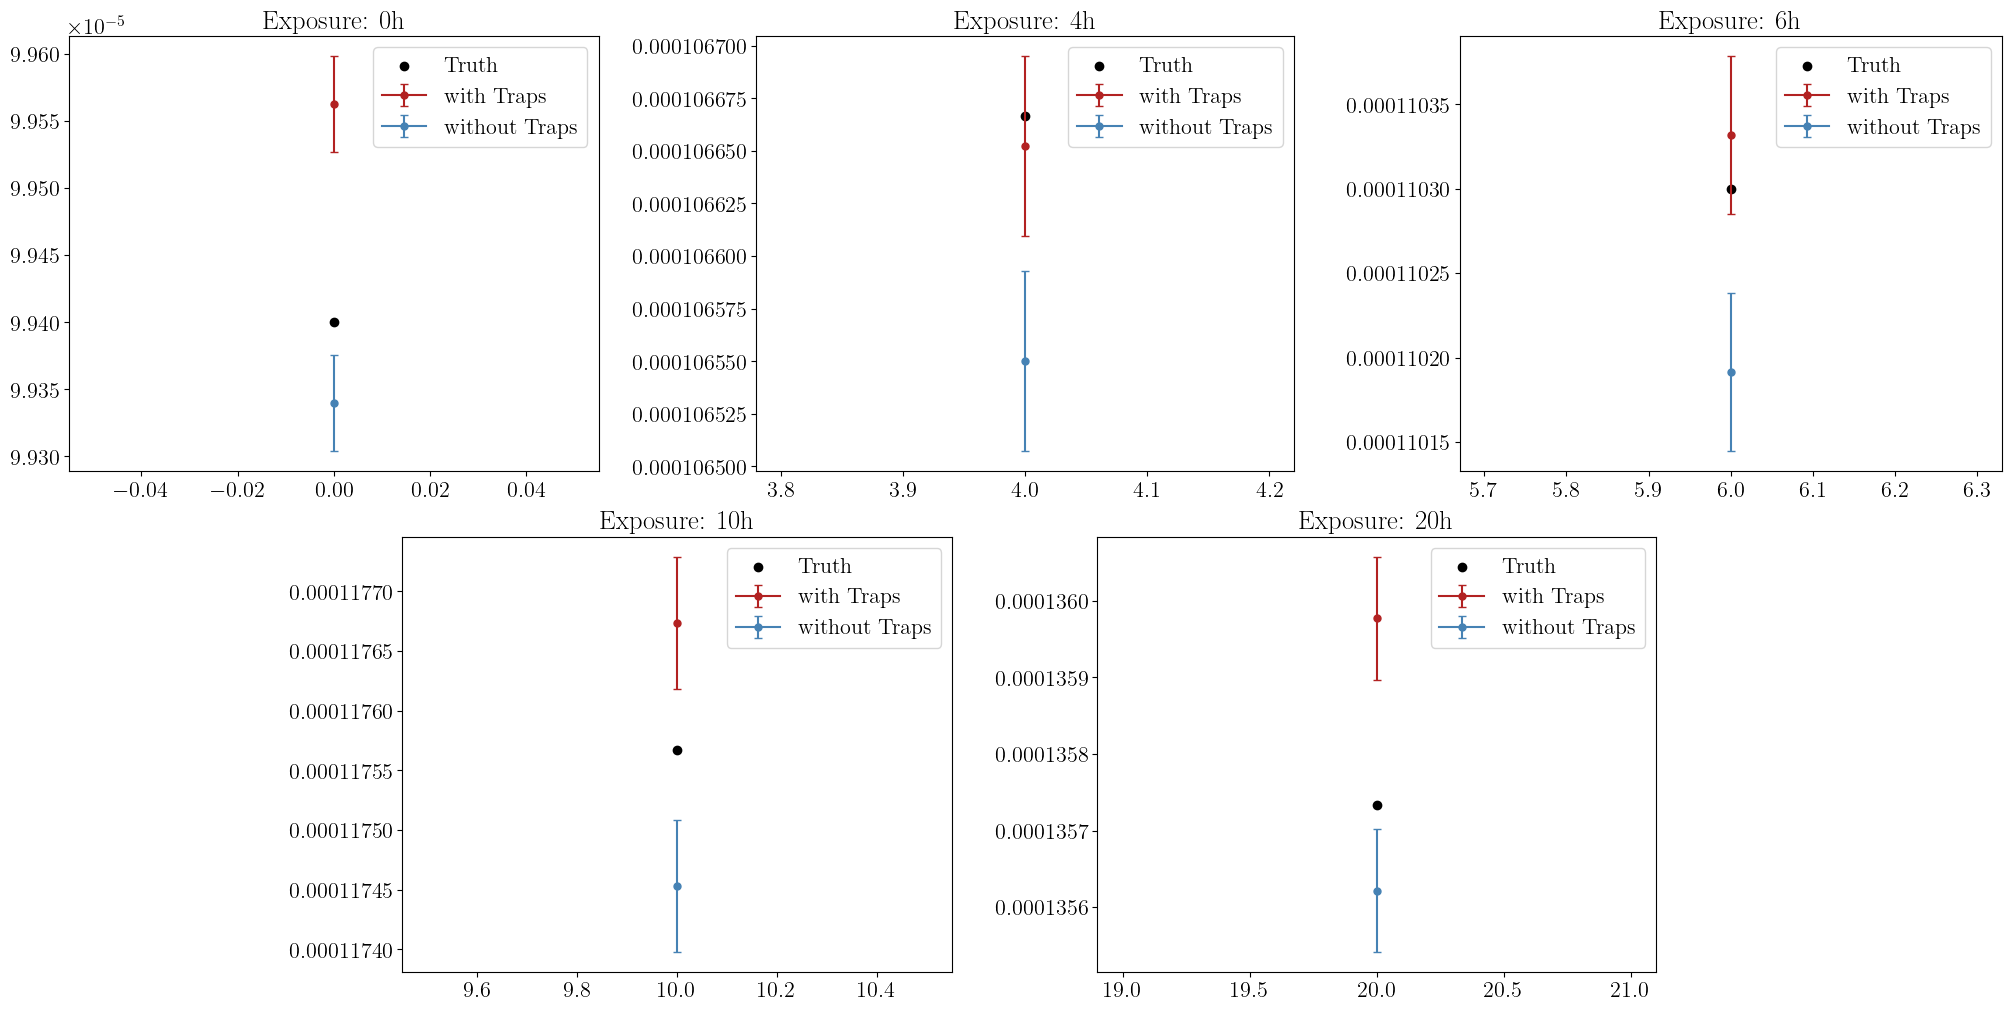

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Create some sample data
x = np.linspace(0, 10, 100)
y1, y2, y3 = np.sin(x), np.cos(x), np.sin(x) * np.cos(x)
y4, y5 = np.tan(x), np.tanh(x) # Placeholder data for demonstration

# Define the layout using a mosaic of characters
# 'A', 'B', 'C' are the top three plots
# '.' represents an empty space
# 'D', 'E' are the bottom two, spanning two "virtual" columns each
mosaic = """
AABBCC
.DDEE.
"""

fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(20, 10), constrained_layout=True)
key_list = ['A','B','C','D','E']
# Plot data on each axis
for i in range(len(average_densities)):
    key =key_list[i]
    truth = line(unique_exposures_h[i],UR_expdep,UR_expindep)
    ax_dict[key].errorbar(unique_exposures_h[i],average_densities[i],yerr=average_density_errs[i],label='with Traps',color='firebrick',capsize=3,marker='o',markersize=5)
    # ax_dict[key].scatter(unique_exposures_h[i],average_densities[i],color='firebrick')
    ax_dict[key].errorbar(unique_exposures_h[i],average_densities_notraps[i],yerr=average_density_errs_notraps[i],label='without Traps',color='steelblue',capsize=3,marker='o',markersize=5)
    # ax_dict[key].scatter(unique_exposures_h[i],average_densities_notraps[i],color='steelblue')
    ax_dict[key].scatter(unique_exposures_h[i],truth,color='black',label='Truth')
    ax_dict[key].legend()
    ax_dict[key].set_title(f"Exposure: {unique_exposures_h[i]}h")
# ax_dict['A'].plot(x, y1, 'r')
# ax_dict['A'].set_title('Plot A')

# ax_dict['B'].plot(x, y2, 'g')
# ax_dict['B'].set_title('Plot B')

# ax_dict['C'].plot(x, y3, 'b')
# ax_dict['C'].set_title('Plot C')

# ax_dict['D'].plot(x, y4, 'm')
# ax_dict['D'].set_title('Plot D')

# ax_dict['E'].plot(x, y5, 'c')
# ax_dict['E'].set_title('Plot E')

# Add an overall title and display the figure
# fig.suptitle('Five Plots (3 Top, 2 Bottom)')
plt.show()

    

In [32]:
average_densities,average_density_errs

(array([9.92644519e-05, 1.06496689e-04, 1.10068045e-04, 1.17419252e-04,
        1.35519486e-04]),
 array([3.56293003e-08, 3.74240847e-08, 3.83577669e-08, 4.02017601e-08,
        4.48347953e-08]))

In [33]:
average_densities_notraps,average_density_errs_notraps

(array([9.93490277e-05, 1.06595731e-04, 1.10154406e-04, 1.17477464e-04,
        1.35514428e-04]),
 array([3.56441530e-08, 3.74411527e-08, 3.83724687e-08, 4.02113570e-08,
        4.48335588e-08]))

In [346]:



# def get_poisson_threshold_fast(mu, n_tests, expected_fp):
#     import numpy as np
#     from scipy.stats import poisson
#     """Faster, numerically stable threshold calculator."""
#     alpha = expected_fp / n_tests
#     k_guess = int(poisson.isf(alpha, mu))
#     if np.isnan(k_guess): k_guess = int(mu)
#     k = max(k_guess, int(mu))
#     while poisson.sf(k - 1, mu) > alpha:
#         k += 1
#     return k

# def moving_sum_2d(arr, R, C):
#     import numpy as np
#     """Fast O(N) sliding window sum."""
#     s = np.cumsum(arr, axis=0, dtype=float)
#     s[R:] = s[R:] - s[:-R]
#     s = s[R - 1:]
#     s = np.cumsum(s, axis=1, dtype=float)
#     s[:, C:] = s[:, C:] - s[:, :-C]
#     s = s[:, C - 1:]
#     return np.round(s).astype(int)

# def generate_hot_pixel_mask_convergent(stacked_image, expected_fp=0.5, max_iters=10,verbose=False):
#     import numpy as np
#     H, W = stacked_image.shape
    
#     # 1. Define and Sort Geometries by Area
#     geometries = []
#     for r in range(1, 6):
#         for c in range(1, 6):
#             geometries.append(('pixel', r, c))
#     for c in range(2, 6):
#         geometries.append(('col', H, c))
        
#     W_16 = max(1, W // 16)
#     # geometries.append(('large_col', H, W_16))
    
#     # Sort strictly by Area (R * C)
#     geometries.sort(key=lambda x: x[1] * x[2])
    
#     # 2. Initialize working variables
#     cleaned_stacked_image = stacked_image.copy().astype(float)
#     global_mask = np.zeros((H, W), dtype=bool)
#     if verbose:
#         print(f"\n--- STARTING CONVERGENT MASKING ---")
    
#     # 3. The Convergence Loop
#     for iteration in range(max_iters):
#         if verbose:
#             print(f"\n--- Iteration {iteration} ---")
        
#         # A. Calculate Lambda dynamically
#         if iteration == 0:
#             # First pass: use 99th percentile to guess the cold background
#             threshold_99 = np.percentile(cleaned_stacked_image, 99)
#             valid_pixels = cleaned_stacked_image[cleaned_stacked_image <= threshold_99]
#         else:
#             # Subsequent passes: strictly use pixels that haven't been masked
#             valid_pixels = cleaned_stacked_image[~global_mask]
            
#         lambda_bkg = np.mean(valid_pixels)
#         if verbose:
#             print(f"Current Background Rate: {lambda_bkg:.6f} e-/pix")
        
#         new_pixels_this_iteration = 0
        
#         # B. Cascade through geometries
#         for g_type, R, C in geometries:
#             N_tests = (H - R + 1) * (W - C + 1)
#             if N_tests <= 0: continue
                
#             target_fp = (expected_fp / W_16) if g_type == 'large_col' else expected_fp
#             mu = lambda_bkg * R * C
#             thresh = get_poisson_threshold_fast(mu, N_tests, target_fp)
            
#             window_sums = moving_sum_2d(cleaned_stacked_image, R, C)
#             bad_i, bad_j = np.where(window_sums >= thresh)
            
#             if len(bad_i) > 0:
#                 diff_mask = np.zeros((H + 1, W + 1), dtype=int)
#                 np.add.at(diff_mask, (bad_i, bad_j), 1)
#                 np.add.at(diff_mask, (bad_i + R, bad_j), -1)
#                 np.add.at(diff_mask, (bad_i, bad_j + C), -1)
#                 np.add.at(diff_mask, (bad_i + R, bad_j + C), 1)
                
#                 coverage = np.cumsum(np.cumsum(diff_mask, axis=0), axis=1)
#                 step_mask = coverage[:-1, :-1] > 0
                
#                 # Check how many NEW pixels we are masking right now
#                 new_in_step = np.sum(step_mask & ~global_mask)
#                 new_pixels_this_iteration += new_in_step
                
#                 if new_in_step > 0:
#                     # Clean the image so larger blocks don't trip over these defects
#                     cleaned_stacked_image[step_mask] = lambda_bkg
#                     global_mask |= step_mask
#         if verbose:
#             print(f"Total NEW pixels masked in this iteration: {new_pixels_this_iteration}")
        
#         # C. Convergence Check
#         if new_pixels_this_iteration == 0:
#             if verbose:
#                 print(f"\n=> Convergence reached at iteration {iteration}! No new hot pixels found.")
#             break
            
#     if iteration == max_iters - 1 and new_pixels_this_iteration > 0:
#         # if verbose:
#         print(f"\n=> Warning: Reached max_iters ({max_iters}) without full convergence.")
#     if verbose:
#         print(f"----------------------------------------")
#         print(f"Final Total Pixels Masked: {np.sum(global_mask)} / {H*W}")
#         print(f"----------------------------------------\n")
    
#     return global_mask 



In [347]:
520*3096

1609920

In [89]:
from utils import *
target_shape=(520, 3200)

                                    # count_threshold=20, max_aspect_ratio=3.0, 
                                    # radius=20,exposure=72000,scale_factor = 1):
from skimage.morphology import dilation, disk
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
import numpy as np

file = 'minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits'

source_image = get_qdata(file,0)

source_image =approximate_electronize(source_image,400)

labeled_array, num_features = ndimage.label(source_image > 0)
cluster_slices = ndimage.find_objects(labeled_array)
cluster_sums = ndimage.sum(source_image, labeled_array, index=np.arange(1, num_features + 1))

new_image = np.zeros(target_shape, dtype=source_image.dtype)
img_h, img_w = new_image.shape
src_h, src_w = source_image.shape
rng = np.random.default_rng()

totClusters = num_features
# Calculate how many we WANT to process
# target_num_clusters = int(np.round(scale_factor * (exposure / 72000) * num_features))
totClusters

1024